# Two Dimension Random Walk Simulation
---

*Extending Monte Carlo Simulations to 2D*

## Why 2D?

In 1D, the drunk man could only stumble left or right. Real diffusion happens in
two and three dimensions where particles in liquids, heat spreading across a surface, animals foraging in a field.

In 2D, each step picks one of four directions: up, down, left, right. The distance from origin is now being calculated as √(x² + y²).

---

## 1. One Walk in 2-D :
---
Let us imagine the same man from the last notebook, he is now leaving the bar, but he now has a new ability, i.e, he can walk in all of the any four directions, front, back, left and right or some might say top, down, left and right We simulate the walking upto 1000 steps first.


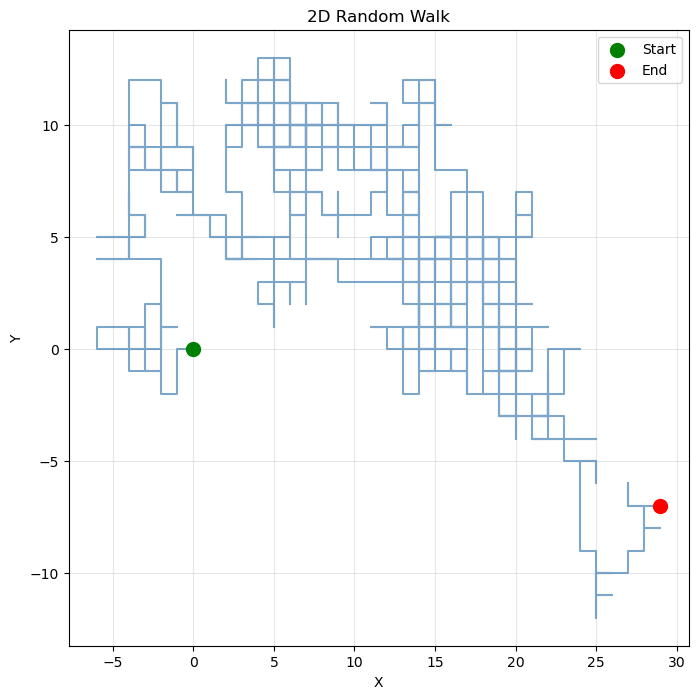

In [5]:
import random
import matplotlib.pyplot as plt

x=y=0
path_x=[0]
path_y=[0]

for i in range(1000):
    dx,dy= random.choice([(1,0),(-1,0),(0,1),(0,-1)])
    x+=dx
    y+=dy
    path_x.append(x)
    path_y.append(y)


plt.figure(figsize=(8,8))
plt.plot(path_x,path_y, color= 'steelblue', alpha=0.7)
plt.scatter(path_x[0], path_y[0], color='green', s=100, zorder=5, label= 'Start')
plt.scatter(path_x[-1], path_y[-1], color='red', s=100, zorder=5, label= 'End')
plt.grid(True, alpha=0.3)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Random Walk')
plt.legend()
plt.show()

**RESULT**

This code gives us a wonderful city like pattern, probably showing us the streets the drunk man meandered after 1000 steps, the blue lines represent the paths he took. But as we saw in the 1D walk that one walk is just a chaos, there is no pattern till now, its just a drunk man walking down on his own.

## 2. Multiple Walk in 2-D:
---

Now let us simulate 500 drunk people walking down the streets trying to get to home and we plot 1000 steps of each people. 

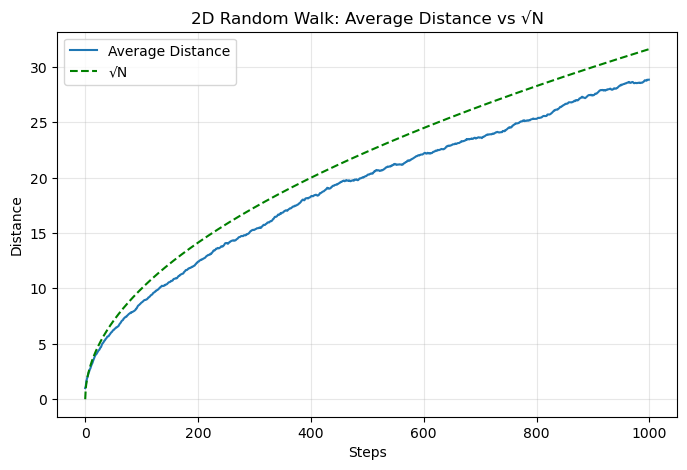

In [11]:
import random
import matplotlib.pyplot as plt
import math

sumdist=[0]*1000

for j in range (500):
    x=y=0
    for i in range(1000):
        dx,dy=random.choice([(1,0),(-1,0),(0,1),(0,-1)])
        x+=dx
        y+=dy
        dist= math.sqrt(abs((x**2)+(y**2)))
        sumdist[i]+= dist

avg=[d/500 for d in sumdist]
steps= range(1000)
root_n= [math.sqrt(n) for n in steps]

plt.figure(figsize=(8, 5))
plt.plot(steps, avg, label='Average Distance')
plt.plot(steps, root_n, linestyle='--', color= 'green', label='√N')
plt.xlabel('Steps')
plt.ylabel('Distance')
plt.title('2D Random Walk: Average Distance vs √N')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**RESULT:**

In 1D, the drunk man's typical distance grew as √N. But 1D is a special case as there are only two directions, so backtracking is unavoidable. Every step has a 50% chance of undoing the previous one.

But with 2D and with four directions (up, down, left, right), the drunk man has more ways to wander away from the bar. Backtracking is less frequent. And as a result, he wanders *farther* in 2D than in 1D, even though the step size is the same.

We run 500 walks, each 1000 steps, and average their distance from the origin at every step. Then we plot it against √N.

The average distance still follows √N — but now with a higher prefactor:

| Dimension | Average Distance / √N |
|-----------|----------------------|
| 1D | ≈ 0.80 |
| 2D | ≈ 0.89 |

The theoretical value in 2D is √π / 2 ≈ 0.886. Our simulation hits it almost
perfectly.

The prefactor reveals something physical: 
>**more dimensions = more freedom to wander**

The same drunk man, the same step size, the same number of steps — but give him more directions to choose from, and he ends up farther.


## 3. Many Walks in Many Cities:
---

Let us imagine that there are 5 cities, and 500 people from each city comes out from a bar (0,0), then wanders off and we calculate 1000 steps of them each. We simulate this specific scenario with our code:

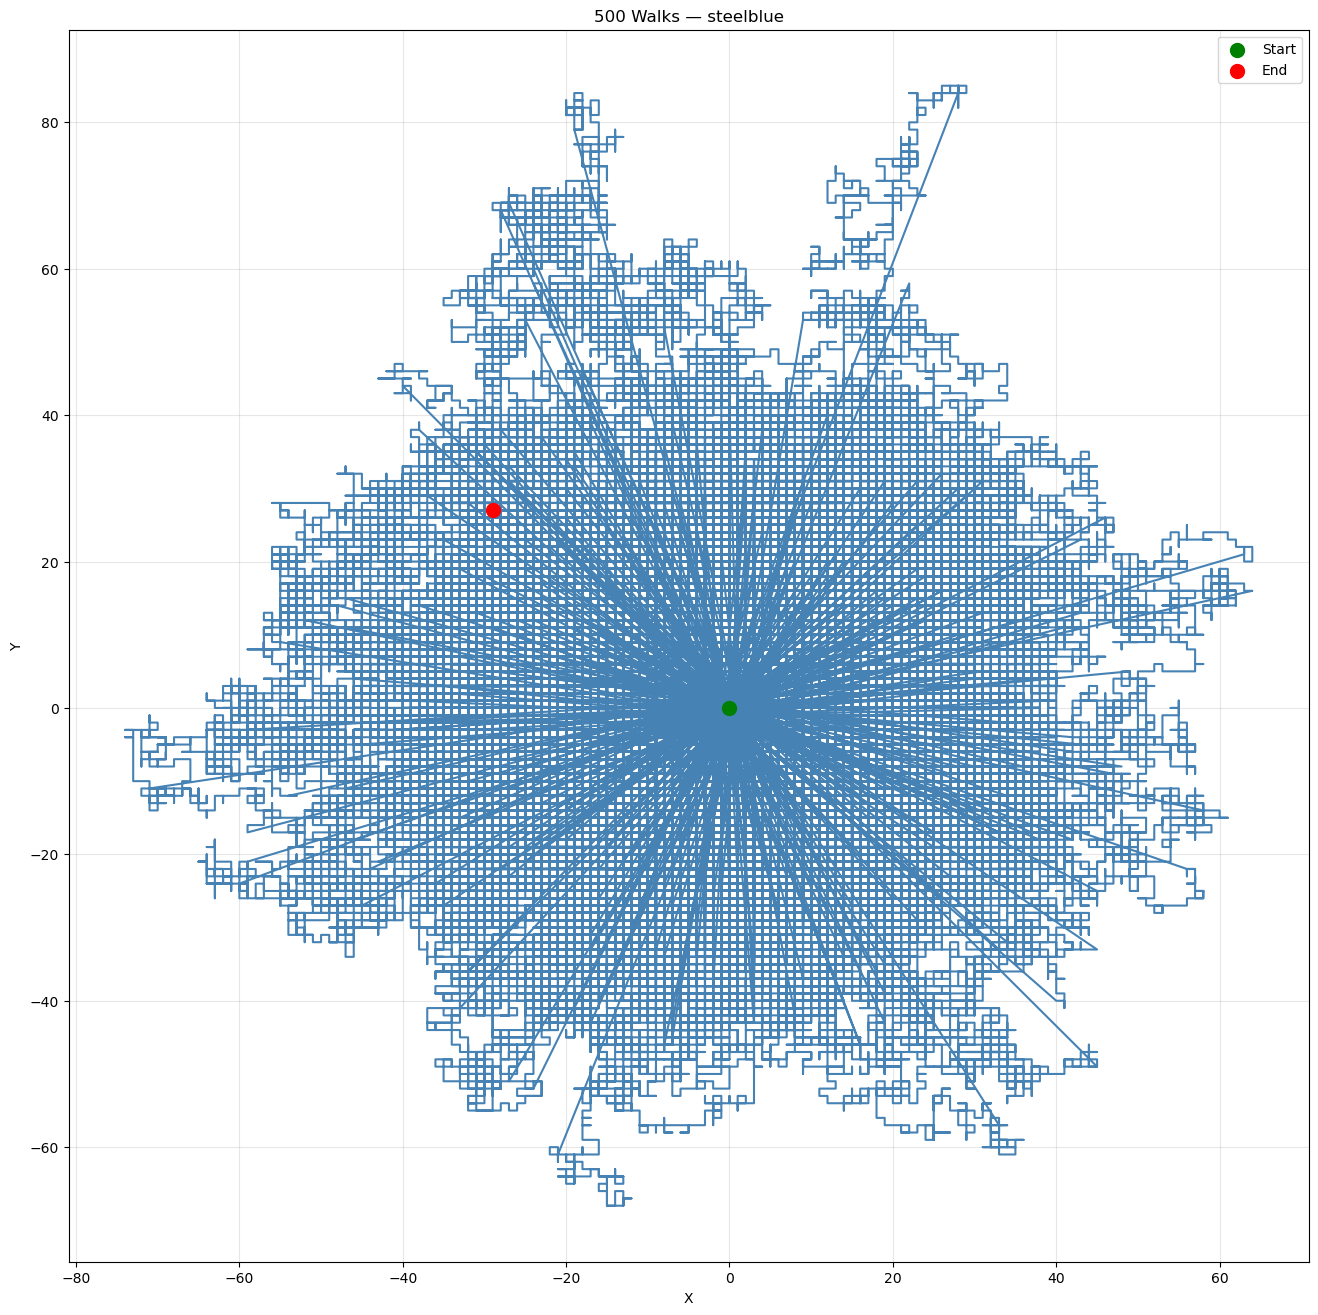

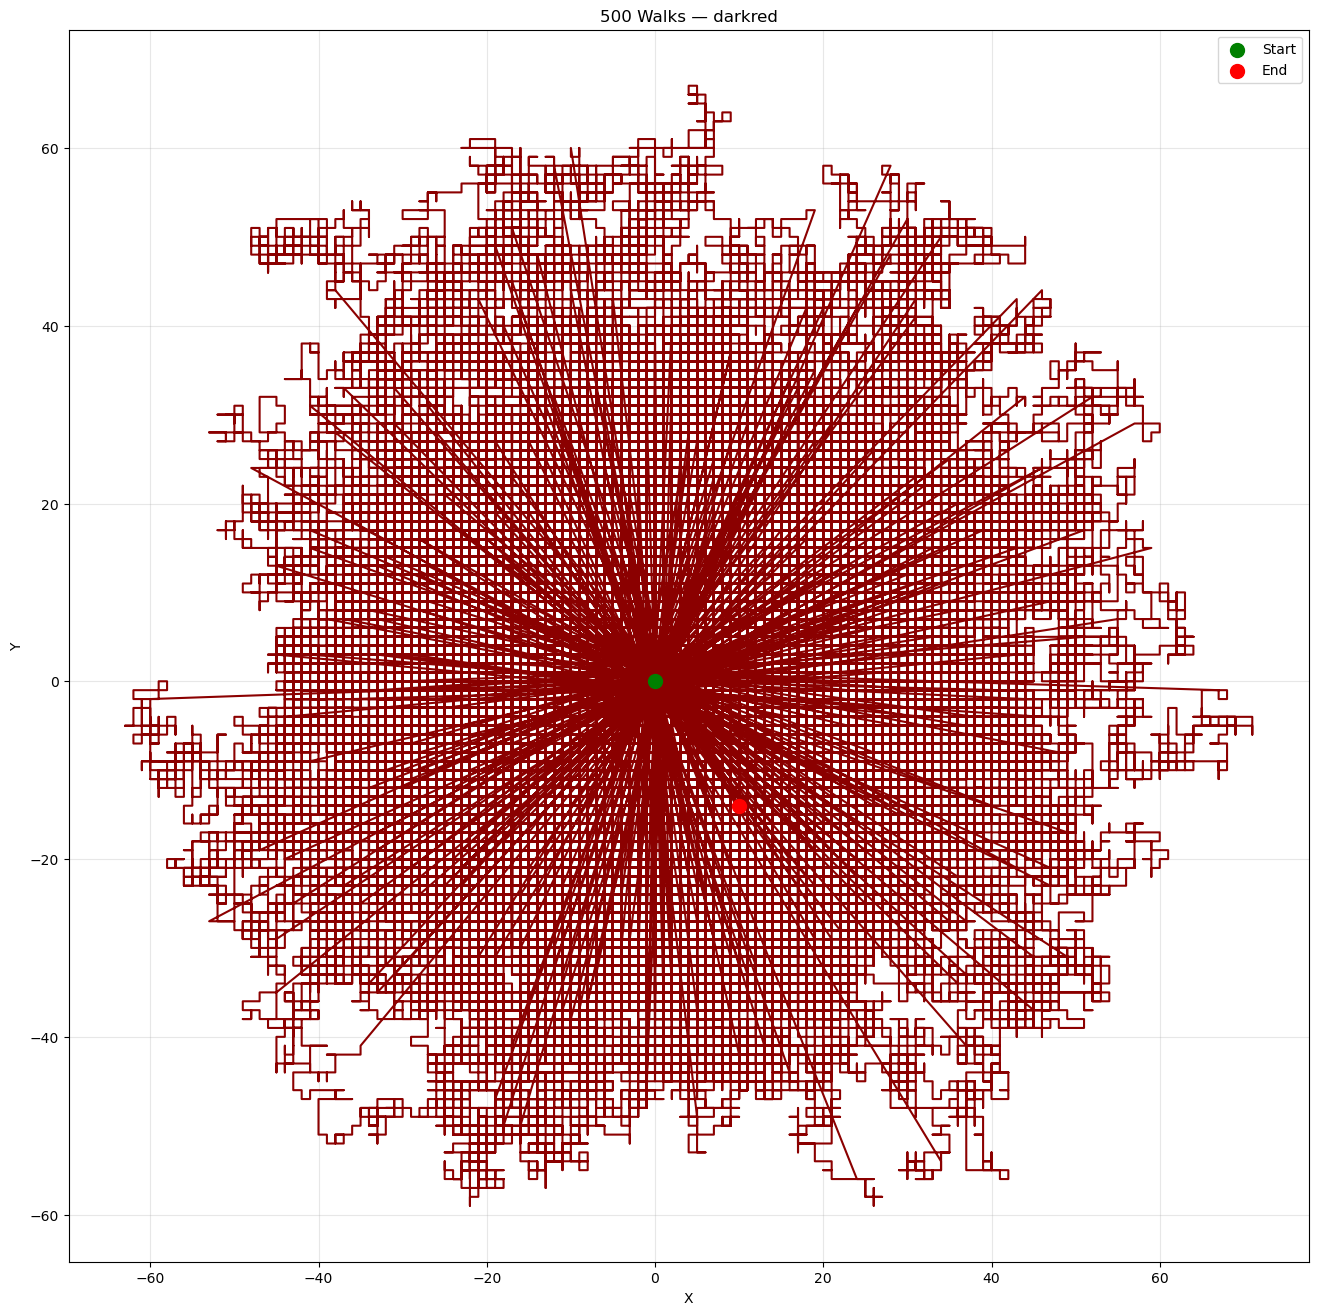

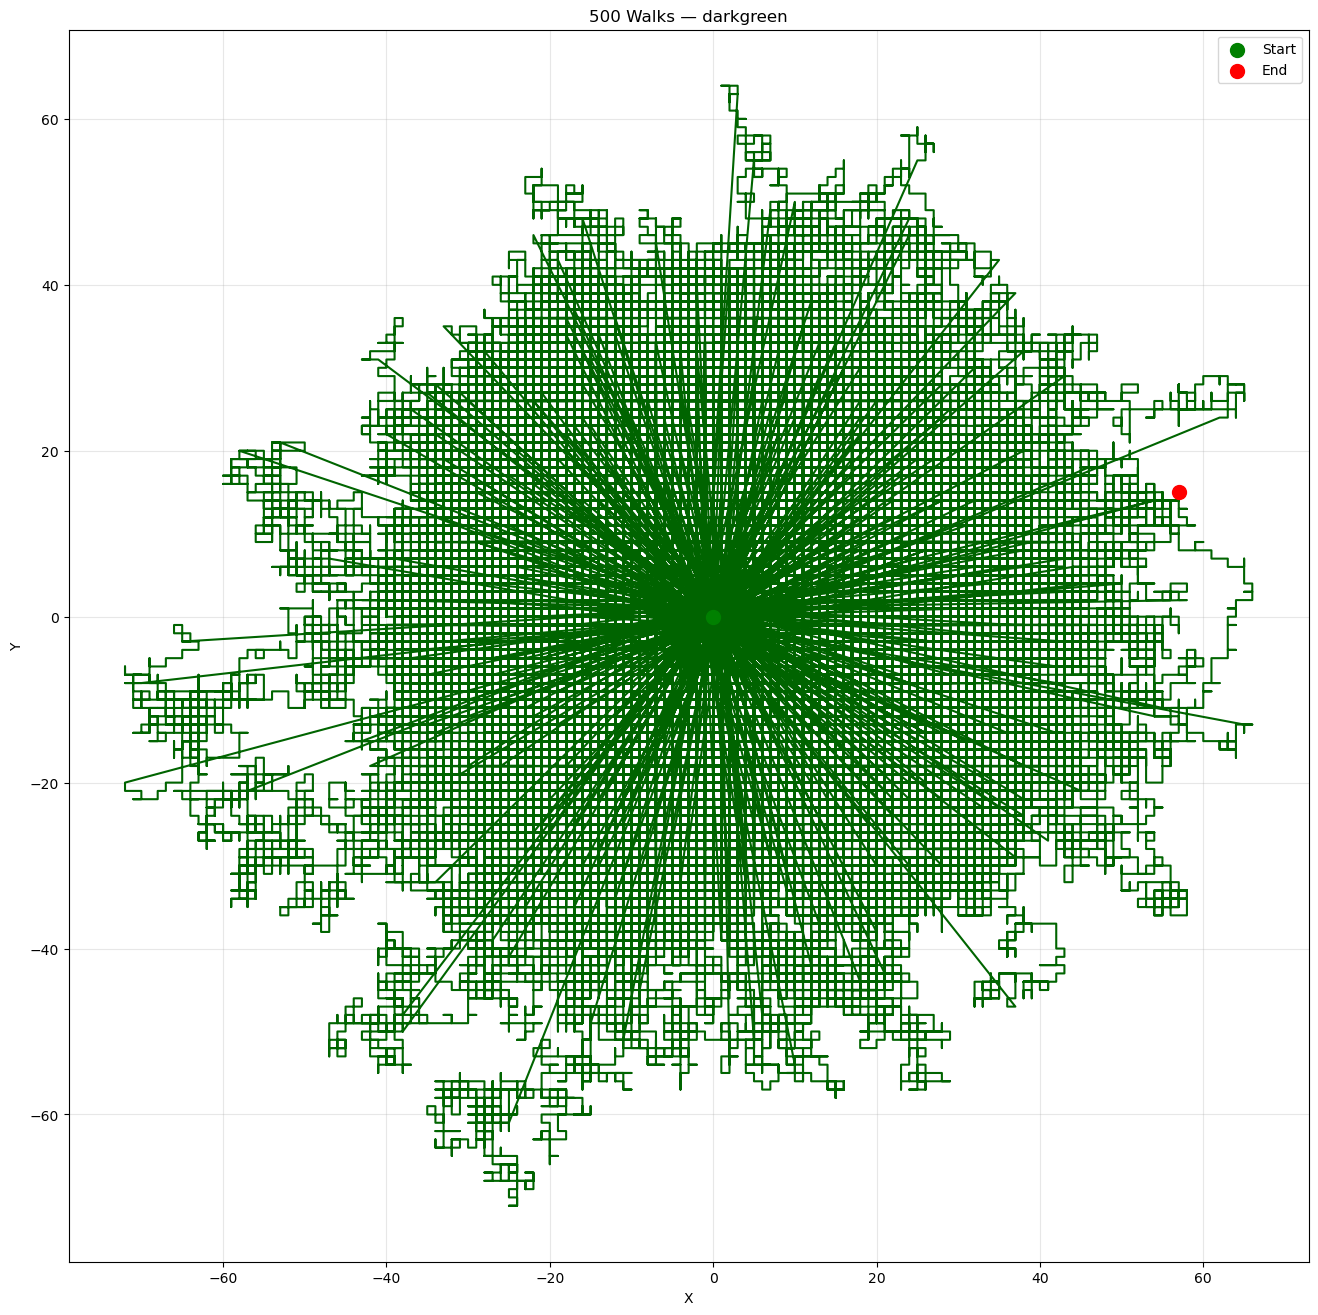

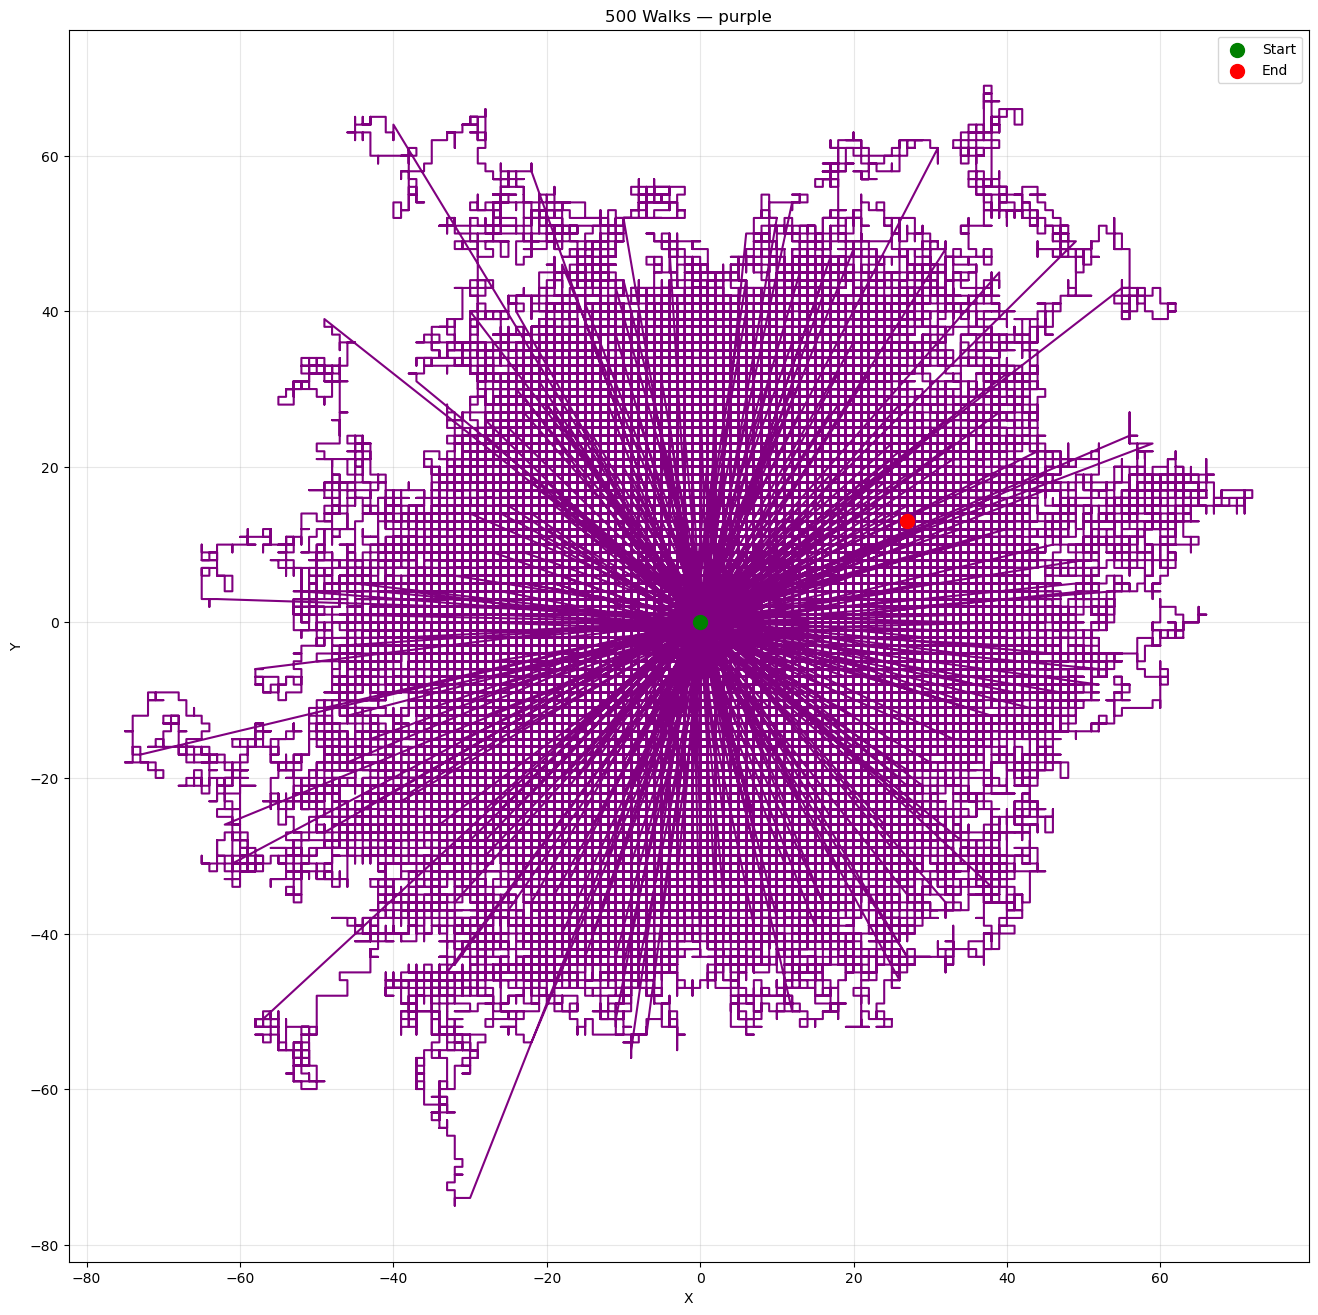

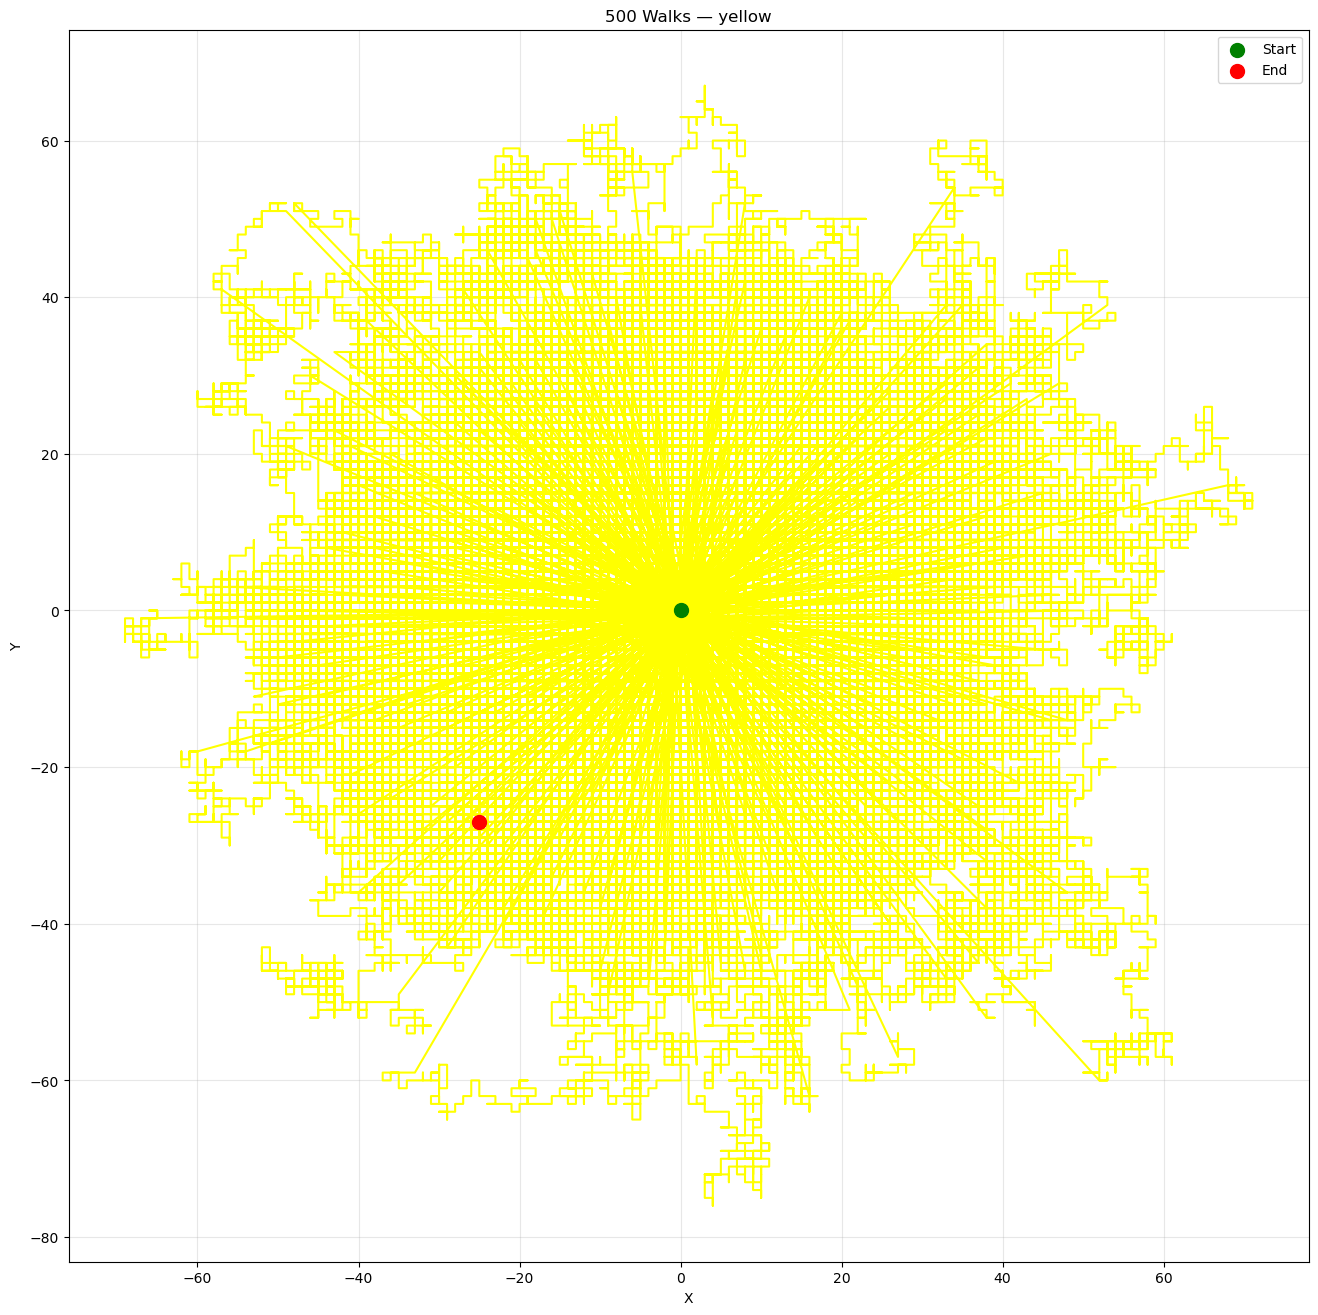

In [14]:
import random
import matplotlib.pyplot as plt


colors=['steelblue','darkred','darkgreen','purple', 'yellow']

for n in colors:
    path_x=[0]
    path_y=[0]
    for j in range (500):
        x=y=0
        for i in range(1000):
            dx,dy=random.choice([(1,0),(-1,0),(0,1),(0,-1)])
            x+=dx
            y+=dy
            path_x.append(x)
            path_y.append(y)
    plt.figure(figsize=(16,16))
    plt.plot(path_x, path_y, color= n)
    plt.scatter(path_x[0],path_y[0], color= 'green', s=100, zorder=5, label="Start")
    plt.scatter(path_x[-1], path_y[-1], color='red', s=100, zorder=5, label= "End")
    plt.grid(True, alpha=0.3)
    plt.title(f'500 Walks — {n}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.show()



**RESULT**


From the graphs we can see that the walks don't scatter randomly across the entire plane. They form a **roughly circular cloud** centered at the origin. The density is highest near the center and fades toward the edges. Almost no walk exceeds a distance of ~80 after 1000 steps.

This shape is not coded into the rules rather each step is purely random up, down, left, or right with equal probability. The circle emerges *from the statistics of many independent random events*.

What we're seeing is a **2D Gaussian (normal) distribution**. After N steps, the probability of finding the drunk man at a given point follows:

$$P(x,y) \propto e^{-(x^2 + y^2) / (2N)}$$

All five cities produce the same pattern — a circular cloud of roughly the same size, regardless of the walk color. The process is stationary: the rules don't change between cities, so neither does the probability distribution.

## 4. Implementing a Boundary - Circular Ditch:
---
There's a **circular ditch** of radius R centered at the origin. If the drunk man's
distance from (0,0) reaches R, he falls in. The walk ends. 

Let us simulate a single walk with the ditch visible as a red circle at R = 10.


Fell after steps= 302


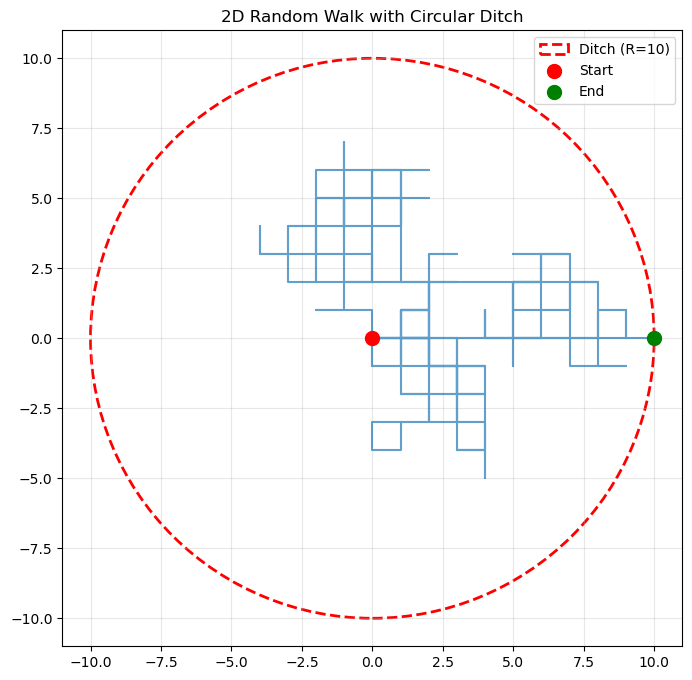

In [22]:
import random
import matplotlib.pyplot as plt
import math

R=10

fell= False
path_x=[0]
path_y=[0]
x=y=0
for i in range(1000):
    dx,dy=random.choice([(1,0),(-1,0),(0,1),(0,-1)])
    x+=dx
    y+=dy
    path_x.append(x)
    path_y.append(y)
    dist= math.sqrt((x**2)+(y**2))
    if dist>=R:
        fell=True
        print(f"Fell after steps= {i+1}")
        break;
if fell== False:
    print("Never Fell")
    

plt.figure(figsize=(8,8))
circle = plt.Circle((0, 0), R, fill=False, color='red', linewidth=2, linestyle='--', label=f'Ditch (R={R})')
plt.gca().add_patch(circle)
plt.plot(path_x, path_y, alpha=0.7)
plt.scatter(path_x[0],path_y[0], color= 'red', s=100, zorder=5, label='Start')
plt.scatter(path_x[-1],path_y[-1], color= 'green',s=100, zorder=5, label= 'End')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('2D Random Walk with Circular Ditch')
plt.show()

The drunk man stumbles around, tracing his grid-like path. Sometimes he wanders
close to the boundary and narrowly escapes. Eventually, he crosses the red circle
and falls. 

Let us use this simulation again for R=60 and see if he gets to survive the fall before the steps run out:


Never Fell


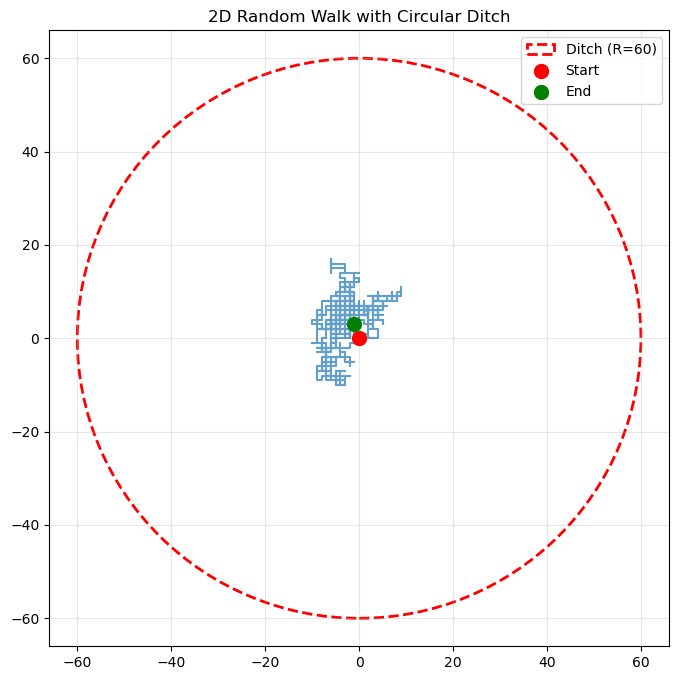

In [24]:
import random
import matplotlib.pyplot as plt
import math

R=60

fell= False
path_x=[0]
path_y=[0]
x=y=0
for i in range(1000):
    dx,dy=random.choice([(1,0),(-1,0),(0,1),(0,-1)])
    x+=dx
    y+=dy
    path_x.append(x)
    path_y.append(y)
    dist= math.sqrt((x**2)+(y**2))
    if dist>=R:
        fell=True
        print(f"Fell after steps= {i+1}")
        break;
if fell== False:
    print("Never Fell")
    

plt.figure(figsize=(8,8))
circle = plt.Circle((0, 0), R, fill=False, color='red', linewidth=2, linestyle='--', label=f'Ditch (R={R})')
plt.gca().add_patch(circle)
plt.plot(path_x, path_y, alpha=0.7)
plt.scatter(path_x[0],path_y[0], color= 'red', s=100, zorder=5, label='Start')
plt.scatter(path_x[-1],path_y[-1], color= 'green',s=100, zorder=5, label= 'End')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('2D Random Walk with Circular Ditch')
plt.show()

Sometimes he survives all 1000 steps without reaching R = 60. The ditch is far
enough that he gets lucky.

## 5. Probability vs the Ditch Radius:
---

As we have seen in the last segment that the ditch radius affects the survival rate of the drunk person. So let us study that with a variety of Ditch Radii


Probability when ditch at 5 is : 1.0
Probability when ditch at 10 is : 1.0
Probability when ditch at 15 is : 1.0
Probability when ditch at 20 is : 0.952
Probability when ditch at 25 is : 0.836
Probability when ditch at 30 is : 0.668
Probability when ditch at 35 is : 0.494
Probability when ditch at 40 is : 0.38
Probability when ditch at 45 is : 0.228
Probability when ditch at 50 is : 0.164
Probability when ditch at 55 is : 0.088
Probability when ditch at 60 is : 0.052
Probability when ditch at 65 is : 0.02
Probability when ditch at 70 is : 0.008
Probability when ditch at 75 is : 0.008
Probability when ditch at 80 is : 0.004
Probability when ditch at 85 is : 0.004
Probability when ditch at 90 is : 0.0
Probability when ditch at 95 is : 0.0
Probability when ditch at 100 is : 0.0


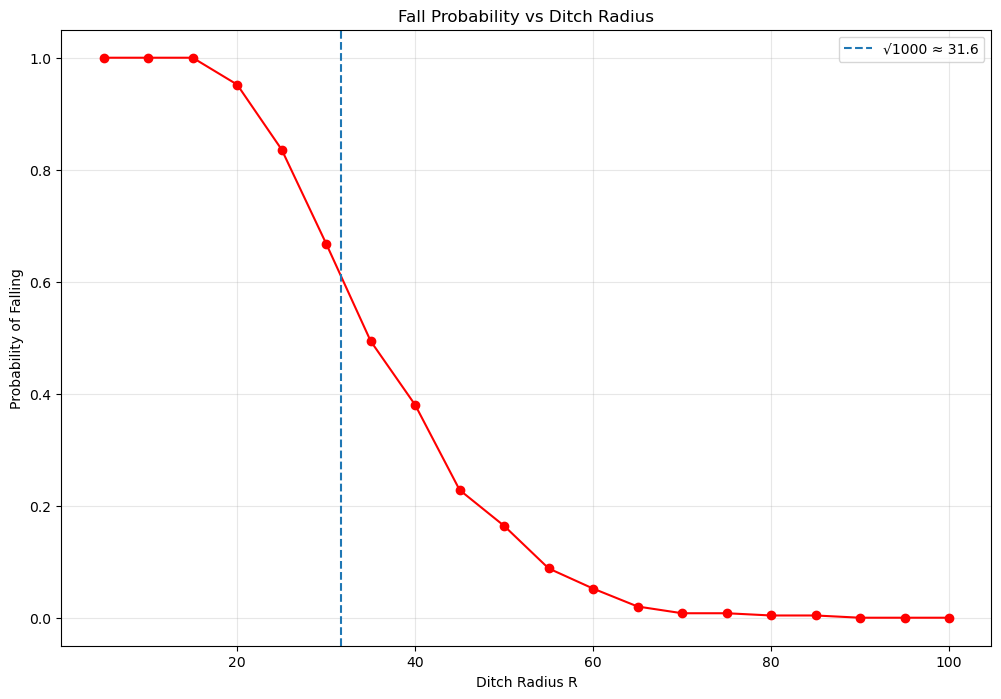

In [34]:
import random
import matplotlib.pyplot as plt
import math

def fall(R):
    x=y=0
    fell=False
    
    for _ in range (1000):
        dx,dy=random.choice([(0,1),(1,0),(-1,0),(0,-1)])
        x+=dx
        y+=dy
        if ((x**2+y**2)**0.5 >=R):
            return True
    return fell
ditch=[]
for i in range(1,21):
    ditch.append(i*5)

allprob=[]
for R in ditch:
    no_f=0
    for _ in range(500):
        if fall(R)==True:
            no_f+=1
        
    prob= no_f/500
    print(f"Probability when ditch at {R} is : {prob}") 
    allprob.append(prob)

plt.figure(figsize=(12,8))
plt.plot(ditch, allprob, marker='o', color='red')
plt.axvline(x=math.sqrt(1000), linestyle='--', label= f'√1000 ≈ {math.sqrt(1000):.1f}')
plt.title("Fall Probability vs Ditch Radius")
plt.xlabel('Ditch Radius R')
plt.ylabel('Probability of Falling')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**RESULT**

The probability curve drops from nearly 100% (small R) to near 0% (large R).
The transition is centered around exactly where we predicted:

$$R_{\text{critical}} = \sqrt{1000} \approx 31.6$$

The same √N that governed the ensemble average distance in Part 2 now appears as
the **critical radius** where survival odds flip. Two completely independent
experiments converge on the same number.

This is actually the diffusion law asserting itself:

> After N steps, the typical displacement is √N.

Boundaries closer than √N will almost certainly be reached. Boundaries farther than √N probably won't be.

## CONCLUSION:
---

After our Random Walk across 1D and 2D we can now summarize the following properties:


| Property | 1D | 2D |
|----------|----|----|
| Directions | 2 (left, right) | 4 (up, down, left, right) |
| Avg distance / √N | ~0.80 | ~0.89 |
| Probability cloud shape | Line segment | Circle |
| Boundary geometry | Two points (±R) | Circle of radius R |

The √N law is robust across dimensions. But dimension controls the **prefactor** —
how efficiently randomness explores space. More dimensions mean less backtracking,
which means farther wandering for the same number of steps.

The **Monte Carlo Method** helps us arrive at this point without even solving a single differential equation or deriving Gaussian Distribution. 


---
